# Canadian Housing Market Analysis: How Does St. John's Compare?

## Introduction
As someone living in St. John's, Newfoundland and Labrador, and actively thinking about buying a home, I wanted to understand where NL sits in the broader Canadian housing market. Are we actually as affordable as people say? How have prices changed over time compared to cities like Toronto and Vancouver?

This project uses Statistics Canada's New Housing Price Index (NHPI) — monthly data spanning from 1981 to 2026 to compare housing price trends across 5 Canadian cities:
St. John's, Halifax, Toronto, Calgary, and Vancouver.

## Data Source
Statistics Canada, Table 18-10-0205-01  New housing price index, monthly.
All values are indexed to December 2016 = 100, meaning prices are measured 
relative to that baseline rather than in dollars.

## Key Question
How has St. John's housing market evolved compared to other Canadian cities, 
and what does that mean for affordability today?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the dataset
df = pd.read_csv('18100205.csv')
# Display the first few rows of the dataset
print(df.head())
print(df.shape)


  REF_DATE              GEO           DGUID New housing price indexes  \
0  1981-01           Canada  2016A000011124    Total (house and land)   
1  1981-01           Canada  2016A000011124                House only   
2  1981-01           Canada  2016A000011124                 Land only   
3  1981-01  Atlantic Region      2016A00011    Total (house and land)   
4  1981-01  Atlantic Region      2016A00011                House only   

                 UOM  UOM_ID SCALAR_FACTOR  SCALAR_ID      VECTOR  COORDINATE  \
0  Index, 201612=100     347         units          0  v111955442         1.1   
1  Index, 201612=100     347         units          0  v111955443         1.2   
2  Index, 201612=100     347         units          0  v111955444         1.3   
3  Index, 201612=100     347         units          0  v111955445         2.1   
4  Index, 201612=100     347         units          0  v111955446         2.2   

   VALUE STATUS  SYMBOL  TERMINATED  DECIMALS  
0   38.2    NaN     NaN   

In [4]:
df['GEO'].unique()

array(['Canada', 'Atlantic Region', 'Newfoundland and Labrador',
       "St. John's, Newfoundland and Labrador", 'Prince Edward Island',
       'Charlottetown, Prince Edward Island', 'Nova Scotia',
       'Halifax, Nova Scotia', 'New Brunswick',
       'Saint John, Fredericton, and Moncton, New Brunswick', 'Quebec',
       'Québec, Quebec', 'Sherbrooke, Quebec', 'Trois-Rivières, Quebec',
       'Montréal, Quebec', 'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
       'Ontario', 'Ottawa-Gatineau, Ontario part, Ontario/Quebec',
       'Oshawa, Ontario', 'Toronto, Ontario', 'Hamilton, Ontario',
       'St. Catharines-Niagara, Ontario',
       'Kitchener-Cambridge-Waterloo, Ontario', 'Guelph, Ontario',
       'London, Ontario', 'Windsor, Ontario', 'Greater Sudbury, Ontario',
       'Prairie Region', 'Manitoba', 'Winnipeg, Manitoba', 'Saskatchewan',
       'Regina, Saskatchewan', 'Saskatoon, Saskatchewan', 'Alberta',
       'Calgary, Alberta', 'Edmonton, Alberta', 'British Columbia',
     

In [5]:
df.isnull().sum()

REF_DATE                         0
GEO                              0
DGUID                         1632
New housing price indexes        0
UOM                              0
UOM_ID                           0
SCALAR_FACTOR                    0
SCALAR_ID                        0
VECTOR                           0
COORDINATE                       0
VALUE                        10826
STATUS                       36028
SYMBOL                       65280
TERMINATED                   65280
DECIMALS                         0
dtype: int64

In [6]:
print(df['REF_DATE'].min())
print(df['REF_DATE'].max())

1981-01
2026-04


In [14]:
df_filtered = df[df['GEO'].isin(["St. John's, Newfoundland and Labrador", "Toronto, Ontario", "Vancouver, British Columbia", "Calgary, Alberta", "Halifax, Nova Scotia"])]
print(df_filtered.shape)

df_filtered = df_filtered[df_filtered['New housing price indexes'] == 'Total (house and land)']
df_filtered = df_filtered[['REF_DATE', 'GEO', 'VALUE']]
print(df_filtered.shape)

(8160, 15)
(2720, 3)


In [17]:
df_filtered['REF_DATE'] = pd.to_datetime(df_filtered['REF_DATE'])
print(df_filtered.dtypes)

REF_DATE    datetime64[ns]
GEO                 object
VALUE              float64
dtype: object


## 1. Housing Price Trends Over Time (1981–2026)

The first step is getting a broad view of how housing prices have changed 
across all 5 cities over the full 45 year period. Each city's price is measured 
against a baseline of 100 (December 2016), so we can make fair comparisons 
regardless of actual dollar values.

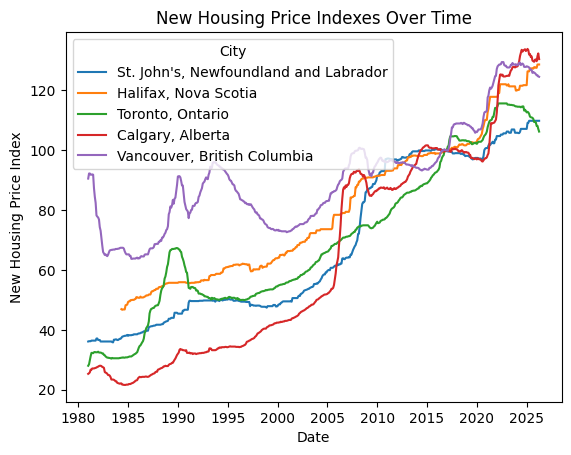

In [21]:
sns.lineplot(data=df_filtered, x='REF_DATE', y='VALUE', hue='GEO')
plt.title('New Housing Price Indexes Over Time')
plt.xlabel('Date')
plt.ylabel('New Housing Price Index')
plt.legend(title='City')
plt.show()

### What We Found
St. John's remained one of the most affordable cities through the 1980s, 1990s, 
and 2000s, growing slowly and steadily compared to cities like Vancouver which 
showed dramatic volatility as early as the 1980s. The most striking pattern is 
the sharp post 2020 surge across all cities, a clear signal of the pandemic era housing boom.

In [22]:
df_filtered['decade'] = df_filtered['REF_DATE'].dt.year // 10 * 10
print(df_filtered.head())

      REF_DATE                                    GEO  VALUE  decade
9   1981-01-01  St. John's, Newfoundland and Labrador   36.1    1980
21  1981-01-01                   Halifax, Nova Scotia    NaN    1980
57  1981-01-01                       Toronto, Ontario   28.0    1980
102 1981-01-01                       Calgary, Alberta   25.3    1980
114 1981-01-01            Vancouver, British Columbia   90.5    1980


## 2. Average Housing Price Index by Decade

Breaking the data into decades smooths out short term volatility and reveals 
longer term structural shifts. This chart shows the average price index for 
each city per decade, making it easier to see when and where prices accelerated.

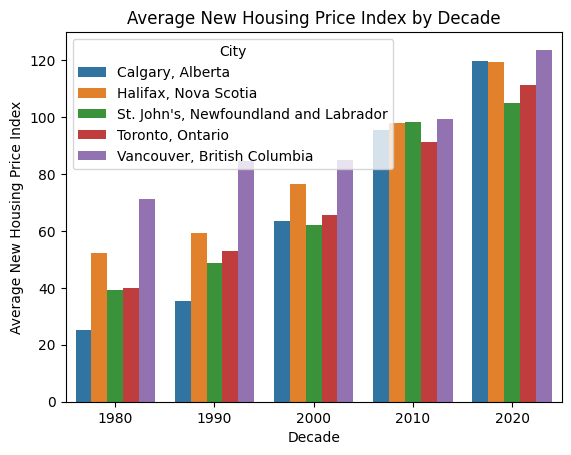

In [30]:
decade_avg = df_filtered.groupby(['decade', 'GEO'])['VALUE'].mean()
decade_avg = decade_avg.reset_index()
plt.title('Average New Housing Price Index by Decade')
plt.xlabel('Decade')
plt.ylabel('Average New Housing Price Index')
sns.barplot(data=decade_avg, x='decade', y='VALUE', hue='GEO').legend(title='City')

### What We Found
St. John's consistently sat among the most affordable cities decade over decade, only beginning to close the gap in the 2010s. Calgary tells a dramatic story of oil boom wealth, jumping sharply in the 2010s before leveling off. Perhaps most surprisingly, Vancouver which appears volatile in the full timeline, shows relatively modest decade averages because its early 1980s prices were already high before the index baseline was set.

In [31]:
df_pandemic = df_filtered[df_filtered['REF_DATE'] >= '2020-01-01']
print(df_pandemic.shape)

(380, 4)


## 3. The Pandemic Housing Boom (2020–2026)

The post 2020 period represents the most dramatic shift in Canadian housing 
in decades. This chart zooms into that period to examine how each city 
responded to the pandemic era surge in demand, low interest rates, and 
remote work driven migration patterns.

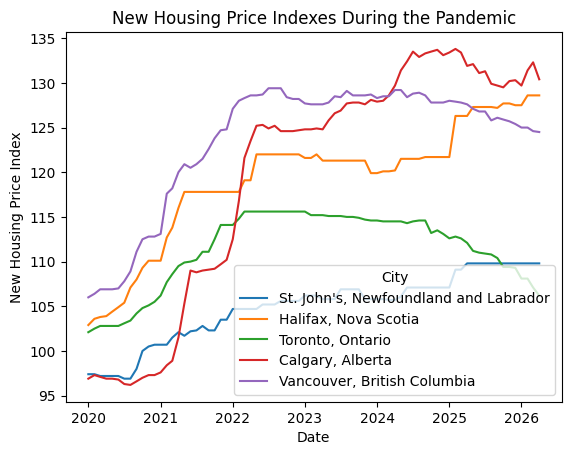

In [32]:
sns.lineplot(data=df_pandemic, x='REF_DATE', y='VALUE', hue='GEO')
plt.title('New Housing Price Indexes During the Pandemic')
plt.xlabel('Date')
plt.ylabel('New Housing Price Index')
plt.legend(title='City')

### What We Found
Every city experienced a sharp price increase beginning in 2021, but the 
magnitude and duration varied significantly. Calgary surged the highest and 
has remained elevated. Toronto and Vancouver both peaked around 2022 and have 
since shown signs of correction. Halifax climbed steadily throughout the entire 
period. St. John's saw the most modest increase of all five cities, suggesting 
the market here never overheated the way larger urban centres did. For a 
prospective homebuyer in St. John's, this is a meaningful finding.

In [33]:
df_clean = df_filtered.dropna(subset=['VALUE'])
first_values = df_clean.groupby('GEO')['VALUE'].first()
last_values = df_clean.groupby('GEO')['VALUE'].last()
print(first_values)
print(last_values)

GEO
Calgary, Alberta                         25.3
Halifax, Nova Scotia                     46.9
St. John's, Newfoundland and Labrador    36.1
Toronto, Ontario                         28.0
Vancouver, British Columbia              90.5
Name: VALUE, dtype: float64
GEO
Calgary, Alberta                         130.4
Halifax, Nova Scotia                     128.6
St. John's, Newfoundland and Labrador    109.8
Toronto, Ontario                         106.2
Vancouver, British Columbia              124.5
Name: VALUE, dtype: float64


In [34]:
growth_rate = (last_values - first_values) / first_values * 100
print(growth_rate)

GEO
Calgary, Alberta                         415.415020
Halifax, Nova Scotia                     174.200426
St. John's, Newfoundland and Labrador    204.155125
Toronto, Ontario                         279.285714
Vancouver, British Columbia               37.569061
Name: VALUE, dtype: float64


## 4. Total Housing Price Growth Since 1981

While the previous charts show trends over time, this chart cuts straight to 
the bottom line. Which city has seen the most total growth since data collection began in 1981? This gives us a sense of long term investment performance and how much prices have multiplied from their starting point.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Calgary, Alberta'),
  Text(1, 0, 'Halifax, Nova Scotia'),
  Text(2, 0, "St. John's, Newfoundland and Labrador"),
  Text(3, 0, 'Toronto, Ontario'),
  Text(4, 0, 'Vancouver, British Columbia')])

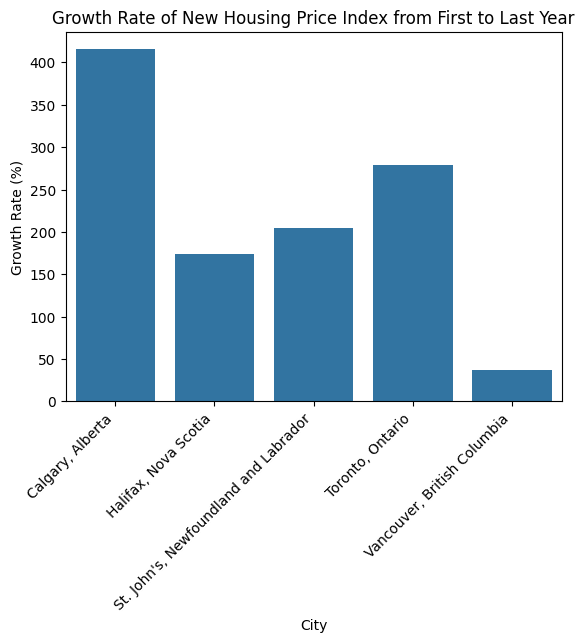

In [38]:
growth_df = growth_rate.reset_index()
growth_df.columns = ['GEO', 'Growth Rate (%)']
sns.barplot(data=growth_df, x='GEO', y='Growth Rate (%)')
plt.title('Growth Rate of New Housing Price Index from First to Last Year')
plt.xlabel('City')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45, ha='right')


### What We Found
Calgary shows the highest percentage growth at over 400%, but this is largely 
because it started from a very low base in 1981. Vancouver on the other hand 
shows the lowest percentage growth because it was already one of Canada's most 
expensive markets four decades ago. St. John's sits in the middle at around 
204% growth, outpacing Halifax and nearly matching Toronto. This reframes the 
affordability story. NL housing has actually grown significantly in relative 
terms, it simply started from a much lower baseline.

In [39]:
df['REF_DATE'] = pd.to_datetime(df['REF_DATE'])
df_canada = df[(df['GEO'] == 'Canada') & (df['New housing price indexes'] == 'Total (house and land)') & (df['REF_DATE'] >= '2000-01-01')  & (df['REF_DATE'] <= '2023-12-31')] 
df_canada = df_canada[['REF_DATE', 'GEO', 'VALUE']]
print(df_canada.shape)

(288, 3)


In [43]:
df_stjohns = df_filtered[(df_filtered['GEO'] == "St. John's, Newfoundland and Labrador") & (df_filtered['REF_DATE'] >= '2000-01-01') & (df_filtered['REF_DATE'] <= '2023-12-31')]
print(df_stjohns.shape)

(288, 4)


## 5. St. John's vs The National Average (2000–2023)

By comparing St. John's directly against the Canadian national average over the past two decades, we can see exactly how NL's housing market has tracked relative to the country as a whole, including the critical post 2020 period.

(576, 4)


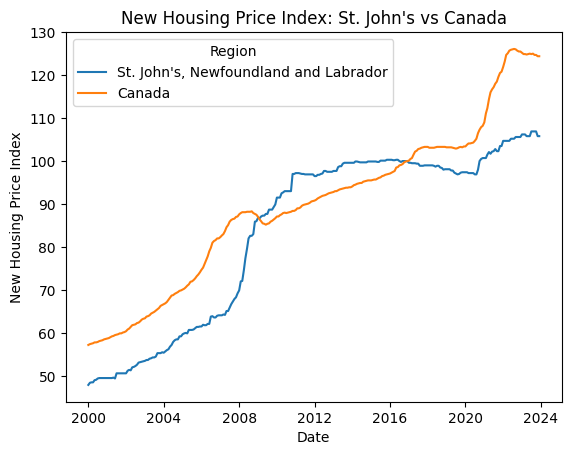

In [44]:
df_spotlight = pd.concat([df_stjohns, df_canada])
print(df_spotlight.shape)
sns.lineplot(data=df_spotlight, x='REF_DATE', y='VALUE', hue='GEO')
plt.title('New Housing Price Index: St. John\'s vs Canada')
plt.xlabel('Date')
plt.ylabel('New Housing Price Index')
plt.legend(title='Region')
plt.show()

### What We Found
St. John's tracked closely with the national average through the mid 2000s, 
likely buoyed by the offshore oil industry driving economic growth in NL. 
However from around 2015 onwards the two lines diverge sharply. The national 
average surged dramatically post 2020 while St. John's grew at a much more 
measured pace. Today St. John's sits well below the national average, making 
it one of the most affordable housing markets in Canada relative to the 
rest of the country. For anyone considering buying a home in St. John's, 
this data suggests the city remains a genuine outlier in an otherwise 
expensive national market.

## Conclusion

This analysis set out to answer a simple question: how does St. John's compare 
to the rest of Canada when it comes to housing prices? After examining 45 years 
of Statistics Canada data, a clear picture emerges.

St. John's has always been affordable relative to major Canadian cities, but 
the gap has widened significantly in the post-pandemic era. While Toronto, 
Vancouver, Calgary and Halifax all experienced dramatic price surges after 2020, 
St. John's grew modestly and remains well below the national average today.

A few caveats worth noting. The New Housing Price Index measures new home 
construction prices, not the broader resale market. Wage differences between 
provinces also play a role in true affordability that this index alone does not 
capture. A natural next step for this analysis would be incorporating income 
data alongside housing prices to build a true affordability ratio.

Overall this project confirmed my suspicion that St. John's is an affordable 
place to buy a home — but the data made that story far more compelling and 
nuanced than I expected.